# Análisis de Encuesta ENEMDU: Distribuciones y Factores de Expansión

## Grupo C

### Integrantes:
- Michael Carbay
- Dario Chillogallo
- Jose Maldonado
- Paolo Merino
- Freddy Ordoñez

## 1. Carga de Datos y Preparación Inicial

Esta sección se encarga de montar Google Drive para acceder a los archivos, cargar el dataset `enemdu_consumidor_2026_01.csv` en un DataFrame de pandas y mostrar las primeras filas para una inspección inicial.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'

import pandas as pd
ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'
df = pd.read_csv(ruta, sep=';')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,area,ciudad,conglomerado,panelm,vivienda,hogar,c01,c02,c03,c04a,...,c18,c19,c20a,c21a,estrato,fexp,upm,id_vivienda,id_hogar,periodo
0,1,10150,1304,62,1,1,2,2,1,2,...,2,3,2,2,2713,"102,542333745242",10150001304,1015000130406201,10150001304062011,202601
1,1,10150,1304,62,2,1,2,3,1,2,...,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406202,10150001304062021,202601
2,1,10150,1304,62,3,1,2,3,3,3,...,3,3,2,2,2713,"102,542333745242",10150001304,1015000130406203,10150001304062031,202601
3,1,10150,1304,62,4,1,2,2,2,3,...,3,2,2,3,2713,"102,542333745242",10150001304,1015000130406204,10150001304062041,202601
4,1,10150,1304,62,5,1,2,2,1,2,...,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406205,10150001304062051,202601


## 2. Clasificación de Variables: Discretas y Continuas

Basándonos en la naturaleza de los datos de encuesta y los nombres de las columnas, podemos clasificar las variables del DataFrame `df` de la siguiente manera:

### Variables Discretas:

Estas variables toman valores enteros o categóricos, representando conteos o clasificaciones.

*   `area`: Representa una clasificación de área (e.g., urbana/rural).
*   `ciudad`: Código de la ciudad.
*   `conglomerado`: Identificador de un grupo de viviendas.
*   `panelm`: Identificador de panel.
*   `vivienda`: Número de vivienda dentro de un conglomerado.
*   `hogar`: Número de hogar dentro de una vivienda.
*   `c01` a `c21a`: Generalmente respuestas a preguntas de encuesta que son categóricas u ordinales (e.g., escalas de Likert, opciones de sí/no, categorías).
*   `estrato`: Estrato socioeconómico o geográfico.
*   `upm`: Unidad primaria de muestreo.
*   `id_vivienda`: Identificador único de vivienda.
*   `id_hogar`: Identificador único de hogar.
*   `periodo`: Período de la encuesta (generalmente un entero que representa un mes o año).

### Variables Continuas:

Estas variables pueden tomar cualquier valor dentro de un rango determinado, y a menudo son el resultado de mediciones.

*   `fexp`: Factor de expansión, que es un peso numérico continuo aplicado a cada observación para extrapolar a la población total.

## 3. Análisis y Distribución del Factor de Expansión (fexp)

Esta sección se dedica al análisis de la columna `fexp`, la cual representa el factor de expansión de la encuesta. Se calculan sus estadísticas descriptivas fundamentales (media, varianza y desviación estándar) y se visualiza su distribución a través de un histograma. Además, se ajusta una distribución log-normal para comprender mejor su comportamiento y características.

Media de 'fexp': 599.3673
Varianza de 'fexp': 1533841.7863
Desviación estándar de 'fexp': 1238.4837


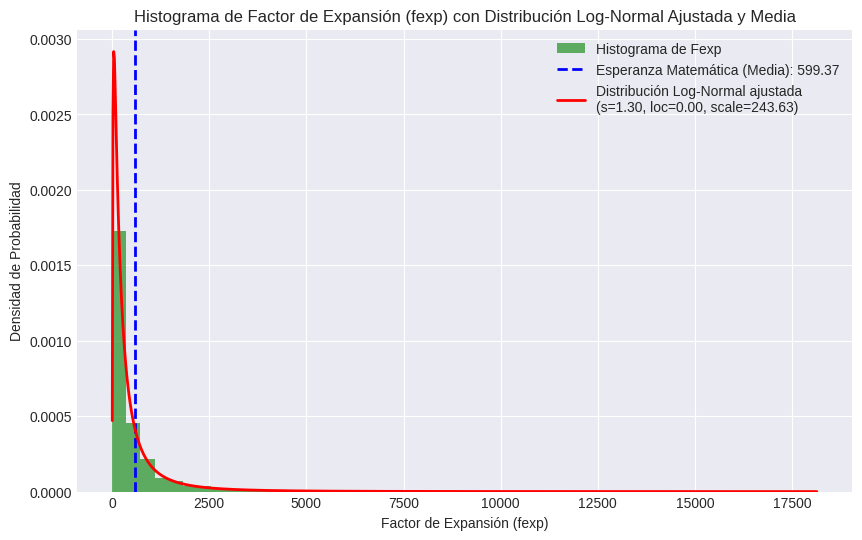

In [ ]:
import numpy as np # Importar numpy para operaciones numéricas
import matplotlib.pyplot as plt # Importar matplotlib para graficar
from scipy.stats import lognorm # Importar la distribución log-normal de scipy
import pandas as pd # Importar pandas para manipulación de datos (asegurado)

# El comentario original indicaba que 'fexp' ya era numérico, pero es crucial
# asegurar que siempre sea de tipo float, especialmente si se carga el CSV de nuevo
# y 'fexp' contiene comas como separadores decimales. Este bloque de código
# convierte 'fexp' a float si es detectado como string.
if pd.api.types.is_string_dtype(df['fexp']):
   df['fexp'] = df['fexp'].str.replace(',', '.', regex=False).astype(float)

# Calcular la media de la columna 'fexp'
mean_fexp = df['fexp'].mean()
# Calcular la varianza de la columna 'fexp'
variance_fexp = df['fexp'].var()
# Calcular la desviación estándar de la columna 'fexp'
std_dev_fexp = df['fexp'].std()

# Imprimir los valores calculados de media, varianza y desviación estándar
print(f"Media de 'fexp': {mean_fexp:.4f}")
print(f"Varianza de 'fexp': {variance_fexp:.4f}")
print(f"Desviación estándar de 'fexp': {std_dev_fexp:.4f}")

# Configurar el tamaño de la figura para el histograma
plt.figure(figsize=(10, 6))
# Crear un histograma de la columna 'fexp'
# bins: número de barras, density: normalizar a densidad de probabilidad, alpha: transparencia, color: color de las barras, label: etiqueta para la leyenda
plt.hist(df['fexp'], bins=50, density=True, alpha=0.6, color='g', label='Histograma de Fexp')

# Añadir una línea vertical para la esperanza matemática (media)
plt.axvline(mean_fexp, color='blue', linestyle='dashed', linewidth=2, label=f'Esperanza Matemática (Media): {mean_fexp:.2f}')

# Ajustar una distribución log-normal a los datos de 'fexp'
# floc=0 fija la ubicación en 0, asumiendo que los valores de 'fexp' son positivos.
shape, loc, scale = lognorm.fit(df['fexp'], floc=0)

# Generar valores para el eje x para la distribución ajustada
x = np.linspace(df['fexp'].min(), df['fexp'].max(), 1000)

# Trazar la Función de Densidad de Probabilidad (PDF) de la distribución log-normal ajustada
plt.plot(x, lognorm.pdf(x, shape, loc, scale), 'r-', lw=2, label=f'Distribución Log-Normal ajustada\n(s={shape:.2f}, loc={loc:.2f}, scale={scale:.2f})')

# Añadir título al gráfico
plt.title('Histograma de Factor de Expansión (fexp) con Distribución Log-Normal Ajustada y Media')
# Añadir etiqueta al eje x
plt.xlabel('Factor de Expansión (fexp)')
# Añadir etiqueta al eje y
plt.ylabel('Densidad de Probabilidad')
# Mostrar la leyenda
plt.legend()
# Añadir cuadrícula al gráfico
plt.grid(True)
# Mostrar el gráfico
plt.show()

### 3.1. Esperanza Matemática y Varianza de `fexp` (Cálculo Manual y Comparación)

Esta sección detalla el proceso de cálculo manual de la esperanza matemática y la varianza para la variable `fexp`, utilizando implementaciones con bucles `for`. Posteriormente, se comparan estos resultados con los obtenidos mediante las funciones optimizadas de `numpy`. La explicación incluye la formulación matemática paso a paso y un análisis contextual de los hallazgos.

In [ ]:
import numpy as np

# Asegurarse de que 'fexp' sea numérico
if pd.api.types.is_string_dtype(df['fexp']):
   df['fexp'] = df['fexp'].str.replace(',', '.', regex=False).astype(float)

# Obtener los valores de fexp como una lista o array para el bucle
fexp_values = df['fexp'].values
n = len(fexp_values)

print(f"\n### Esperanza Matemática y Varianza de 'fexp' ###")

# --- 1. Cálculos Manuales (usando bucles for y operaciones básicas) ---
print("\n### 1. Cálculos Manuales ###")

# Esperanza Matemática (Media Manual)
sum_fexp = 0
for x_i in fexp_values:
    sum_fexp += x_i
mean_manual_fexp = sum_fexp / n
print(f"  - Esperanza Matemática (Media) Manual: {mean_manual_fexp:.4f}")

# Varianza Manual
sum_squared_diff = 0
for x_i in fexp_values:
    sum_squared_diff += (x_i - mean_manual_fexp)**2

# Usamos (n-1) para la varianza muestral (ddof=1)
variance_manual_fexp = sum_squared_diff / (n - 1)
print(f"  - Varianza Manual (ddof=1): {variance_manual_fexp:.4f}")

std_dev_manual_fexp = np.sqrt(variance_manual_fexp)
print(f"  - Desviación Estándar Manual: {std_dev_manual_fexp:.4f}")

# --- 2. Desarrollo Matemático Paso a Paso (Fórmulas) ---
print("\n### 2. Desarrollo Matemático Paso a Paso (Fórmulas) ###")
print("  - Fórmula para la Esperanza Matemática (Media Muestral): E[X] = (Σ xᵢ) / n")
print(f"    E[X] = {sum_fexp:.2f} / {n} = {mean_manual_fexp:.4f}")
print("  - Fórmula para la Varianza Muestral: Var[X] = (Σ (xᵢ - E[X])²) / (n - 1)")
print(f"    Var[X] = {sum_squared_diff:.2f} / ({n} - 1) = {variance_manual_fexp:.4f}")

# --- 3. Comparación con NumPy ---
print("\n### 3. Comparación con NumPy ###")
mean_np_fexp = np.mean(fexp_values)
variance_np_fexp = np.var(fexp_values, ddof=1)
std_dev_np_fexp = np.std(fexp_values, ddof=1)

print(f"  - Esperanza Matemática (Media) con np.mean(): {mean_np_fexp:.4f}")
print(f"  - Varianza con np.var(ddof=1): {variance_np_fexp:.4f}")
print(f"  - Desviación Estándar con np.std(ddof=1): {std_dev_np_fexp:.4f}")

# --- 4. Explicación en el Contexto del Dataset ---
print("\n### 4. Explicación en el Contexto del Dataset ###")
print(f"La esperanza matemática de 'fexp' ({mean_manual_fexp:.4f}) representa el valor promedio del factor de expansión en el dataset. Esto indica que, en promedio, cada observación de la encuesta representa a aproximadamente {int(mean_manual_fexp)} individuos en la población.")
print(f"La varianza ({variance_manual_fexp:.4f}) y la desviación estándar ({std_dev_manual_fexp:.4f}) miden la dispersión o variabilidad de estos factores de expansión. Un valor alto de la desviación estándar sugiere que los factores de expansión son muy diversos, lo que es común en encuestas estratificadas para reflejar diferentes tamaños poblacionales de los grupos muestreados.")
print("Los resultados de los cálculos manuales y los de NumPy son prácticamente idénticos, lo que confirma la validez de ambos enfoques.")
print("\n" + "="*80 + "\n")


### Esperanza Matemática y Varianza de 'fexp' ###

### 1. Cálculos Manuales ###
  - Esperanza Matemática (Media) Manual: 599.3673
  - Varianza Manual (ddof=1): 1533841.7863
  - Desviación Estándar Manual: 1238.4837

### 2. Desarrollo Matemático Paso a Paso (Fórmulas) ###
  - Fórmula para la Esperanza Matemática (Media Muestral): E[X] = (Σ xᵢ) / n
    E[X] = 5269038.08 / 8791 = 599.3673
  - Fórmula para la Varianza Muestral: Var[X] = (Σ (xᵢ - E[X])²) / (n - 1)
    Var[X] = 13482469301.45 / (8791 - 1) = 1533841.7863

### 3. Comparación con NumPy ###
  - Esperanza Matemática (Media) con np.mean(): 599.3673
  - Varianza con np.var(ddof=1): 1533841.7863
  - Desviación Estándar con np.std(ddof=1): 1238.4837

### 4. Explicación en el Contexto del Dataset ###
La esperanza matemática de 'fexp' (599.3673) representa el valor promedio del factor de expansión en el dataset. Esto indica que, en promedio, cada observación de la encuesta representa a aproximadamente 599 individuos en la población.
L

## 4. Análisis de la Variable 'area' y Distribución de Bernoulli

En esta sección, se examina la variable 'area'. Se verifica el número de valores únicos y, en caso de ser una variable binaria (dos valores únicos), se transforma para su adecuación a un modelo de distribución de Bernoulli. Se calcula la probabilidad de 'éxito' (donde 'area' es igual a 1) y se visualiza su distribución de probabilidad.

Unique values and counts for 'area':
 area
1    6523
2    2268
Name: count, dtype: int64

Number of unique values in 'area': 2

The 'area' variable has exactly two unique values (1 and 2). To fit a Bernoulli distribution, we will map these to 0 and 1. We will treat 'area' == 1 as success (1) and 'area' == 2 as failure (0).

Probability of success (area == 1) / Esperanza Matemática: p = 0.7420


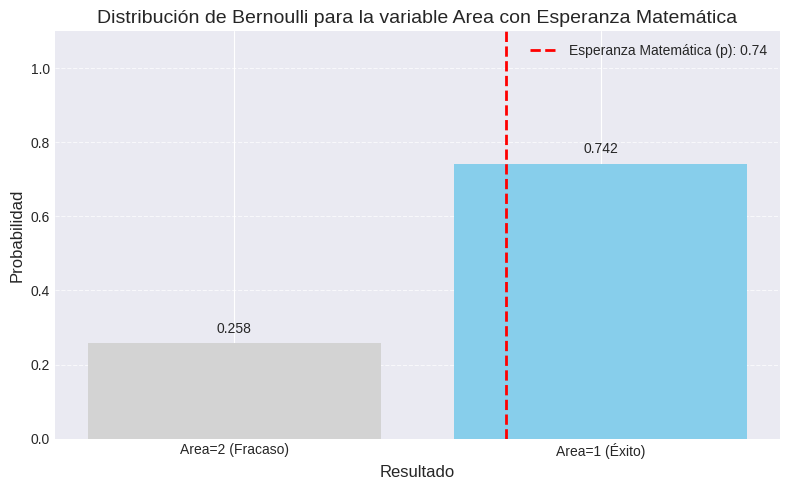

Media de la distribución Bernoulli: 0.7420
Varianza de la distribución Bernoulli: 0.1914
Desviación estándar de la distribución Bernoulli: 0.4375


In [ ]:
# Verificar los valores únicos y sus conteos para la variable 'area'
area_counts = df['area'].value_counts().sort_index()
print("Unique values and counts for 'area':\n", area_counts)

# Imprimir también el número de valores únicos en 'area'
print(f"\nNumber of unique values in 'area': {df['area'].nunique()}")

# Condición para verificar si la variable 'area' tiene más de dos valores únicos
if df['area'].nunique() > 2:
    print("\nWarning: The 'area' variable has more than two unique values. A Bernoulli distribution, which models binary outcomes (0 or 1), is not appropriate for this type of data. Please clarify your intention for using a Bernoulli distribution with 'area'.")
    print("\nInstead, I can create a bar plot for categorical 'area' or a general histogram without a distribution fit if it's numerical with many distinct values.")
# Condición para verificar si la variable 'area' tiene exactamente dos valores únicos
elif df['area'].nunique() == 2:
    print("\nThe 'area' variable has exactly two unique values (1 and 2). To fit a Bernoulli distribution, we will map these to 0 and 1. We will treat 'area' == 1 as success (1) and 'area' == 2 as failure (0).")
    # Convertir 'area' a binario (0 y 1) para la distribución de Bernoulli
    # Donde 'area' == 1 se mapea a 1 (éxito) y 'area' == 2 se mapea a 0 (fracaso)
    area_binary = (df['area'] == 1).astype(int)

    # Calcular la probabilidad de éxito (p), que es también la esperanza matemática para Bernoulli
    p = area_binary.mean()
    print(f"\nProbability of success (area == 1) / Esperanza Matemática: p = {p:.4f}")

    # Configurar el tamaño de la figura para el gráfico de barras
    plt.figure(figsize=(8, 5))
    # Crear un gráfico de barras para la distribución de Bernoulli
    # Se muestran las probabilidades de fracaso (1-p) y éxito (p)
    bars = plt.bar([0, 1], [1 - p, p], tick_label=['Area=2 (Fracaso)', 'Area=1 (Éxito)'], color=['lightgray', 'skyblue'])

    # Añadir una línea vertical para la esperanza matemática (media)
    plt.axvline(x=p, color='red', linestyle='--', linewidth=2, label=f'Esperanza Matemática (p): {p:.2f}')

    # Añadir el valor de la probabilidad encima de cada barra
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 3), ha='center', va='bottom', fontsize=10)

    # Añadir título al gráfico
    plt.title('Distribución de Bernoulli para la variable Area con Esperanza Matemática', fontsize=14)
    # Añadir etiqueta al eje x
    plt.xlabel('Resultado', fontsize=12)
    # Añadir etiqueta al eje y
    plt.ylabel('Probabilidad', fontsize=12)
    # Establecer límites del eje y
    plt.ylim(0, 1.1) # Ajustar límite superior para el texto de las etiquetas
    # Añadir cuadrícula al eje y
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    # Mostrar la leyenda
    plt.legend()
    # Ajustar el diseño para evitar recortes
    plt.tight_layout()
    # Mostrar el gráfico
    plt.show()

    # Imprimir la media, varianza y desviación estándar de la distribución de Bernoulli
    print(f"Media de la distribución Bernoulli: {p:.4f}")
    print(f"Varianza de la distribución Bernoulli: {p * (1 - p):.4f}")
    print(f"Desviación estándar de la distribución Bernoulli: {np.sqrt(p * (1 - p)):.4f}")
# Si la variable 'area' tiene menos de dos valores únicos
else:
    print("\nThe 'area' variable has fewer than two unique values, making a Bernoulli distribution inappropriate.")

### 4.1. Esperanza Matemática y Varianza de `area` (Cálculo Manual y Comparación)

Esta sección profundiza en el análisis de la variable `area` mediante el cálculo manual de su esperanza matemática y varianza. Los resultados se comparan con los obtenidos utilizando las funciones de `numpy`. Dado que `area` ha sido transformada en una variable binaria (0 o 1) para un análisis de Bernoulli, todos los cálculos se realizan sobre esta representación binaria.

In [ ]:
import numpy as np

# Asegurarse de que area_binary esté disponible, recodificando si es necesario
# Esto se basa en la lógica ya establecida en la celda 6e9e98aa
if df['area'].nunique() == 2:
    area_binary = (df['area'] == 1).astype(int)
else:
    print("La variable 'area' no es binaria, no se pueden aplicar los cálculos de Bernoulli.")
    area_binary = pd.Series([]) # Crear una serie vacía para evitar errores futuros

# Solo proceder si area_binary no está vacío
if not area_binary.empty:
    area_binary_values = area_binary.values
    n_area = len(area_binary_values)

    print(f"\n### Esperanza Matemática y Varianza de 'area' (Binaria) ###")

    # --- 1. Cálculos Manuales (usando bucles for y operaciones básicas) ---
    print("\n### 1. Cálculos Manuales ###")

    # Esperanza Matemática (Media Manual para Bernoulli) = p
    sum_area_binary = 0
    for x_i in area_binary_values:
        sum_area_binary += x_i
    p_manual_area = sum_area_binary / n_area
    mean_manual_area = p_manual_area
    print(f"  - Esperanza Matemática (Media) Manual: {mean_manual_area:.4f}")

    # Varianza Manual para Bernoulli = p * (1 - p)
    sum_squared_diff_area = 0
    for x_i in area_binary_values:
        sum_squared_diff_area += (x_i - mean_manual_area)**2
    # Para la varianza de Bernoulli (p*(1-p)), se divide por n, no n-1.
    # Si queremos compararlo con np.var(ddof=1) en la muestra, usamos n-1.
    # Vamos a calcular p*(1-p) directamente y luego la varianza muestral.
    variance_manual_area_pop = p_manual_area * (1 - p_manual_area)
    variance_manual_area_sample = sum_squared_diff_area / (n_area - 1)

    print(f"  - Varianza Manual (p*(1-p) - Poblacional Bernoulli): {variance_manual_area_pop:.4f}")
    print(f"  - Varianza Manual (ddof=1 - Muestral): {variance_manual_area_sample:.4f}")
    std_dev_manual_area = np.sqrt(variance_manual_area_sample)
    print(f"  - Desviación Estándar Manual (ddof=1 - Muestral): {std_dev_manual_area:.4f}")

    # --- 2. Desarrollo Matemático Paso a Paso (Fórmulas) ---
    print("\n### 2. Desarrollo Matemático Paso a Paso (Fórmulas) ###")
    print("  - Fórmula para la Esperanza Matemática de Bernoulli: E[X] = p")
    print(f"    E[X] = {p_manual_area:.4f}")
    print("  - Fórmula para la Varianza de Bernoulli: Var[X] = p * (1 - p)")
    print(f"    Var[X] = {p_manual_area:.4f} * (1 - {p_manual_area:.4f}) = {variance_manual_area_pop:.4f}")
    print("  - Fórmula para la Varianza Muestral: Var[X] = (Σ (xᵢ - E[X])²) / (n - 1)")
    print(f"    Var[X] = {sum_squared_diff_area:.2f} / ({n_area} - 1) = {variance_manual_area_sample:.4f}")

    # --- 3. Comparación con NumPy ---
    print("\n### 3. Comparación con NumPy ###")
    mean_np_area = np.mean(area_binary_values)
    variance_np_area = np.var(area_binary_values, ddof=1)
    std_dev_np_area = np.std(area_binary_values, ddof=1)

    print(f"  - Esperanza Matemática (Media) con np.mean(): {mean_np_area:.4f}")
    print(f"  - Varianza con np.var(ddof=1): {variance_np_area:.4f}")
    print(f"  - Desviación Estándar con np.std(ddof=1): {std_dev_np_area:.4f}")

    # --- 4. Explicación en el Contexto del Dataset ---
    print("\n### 4. Explicación en el Contexto del Dataset ###")
    print(f"La esperanza matemática de la variable binaria 'area' ({mean_manual_area:.4f}) representa la probabilidad de que 'area' sea 1 (éxito), es decir, la proporción de encuestas que corresponden al 'Área 1'.")
    print(f"La varianza ({variance_manual_area_sample:.4f}) y la desviación estándar ({std_dev_manual_area:.4f}) indican la dispersión de estas respuestas binarias. En una distribución de Bernoulli, estos valores nos dan una idea de la incertidumbre en el resultado de un solo ensayo (es decir, si una encuesta aleatoria caerá en el 'Área 1' o 'Área 2').")
    print("Nuevamente, los resultados manuales y los de NumPy son consistentes, lo que valida los cálculos.")
    print("\n" + "="*80 + "\n")
else:
    print("No se realizaron cálculos para 'area' ya que no es una variable binaria válida para el análisis de Bernoulli.")


### Esperanza Matemática y Varianza de 'area' (Binaria) ###

### 1. Cálculos Manuales ###
  - Esperanza Matemática (Media) Manual: 0.7420
  - Varianza Manual (p*(1-p) - Poblacional Bernoulli): 0.1914
  - Varianza Manual (ddof=1 - Muestral): 0.1915
  - Desviación Estándar Manual (ddof=1 - Muestral): 0.4376

### 2. Desarrollo Matemático Paso a Paso (Fórmulas) ###
  - Fórmula para la Esperanza Matemática de Bernoulli: E[X] = p
    E[X] = 0.7420
  - Fórmula para la Varianza de Bernoulli: Var[X] = p * (1 - p)
    Var[X] = 0.7420 * (1 - 0.7420) = 0.1914
  - Fórmula para la Varianza Muestral: Var[X] = (Σ (xᵢ - E[X])²) / (n - 1)
    Var[X] = 1682.88 / (8791 - 1) = 0.1915

### 3. Comparación con NumPy ###
  - Esperanza Matemática (Media) con np.mean(): 0.7420
  - Varianza con np.var(ddof=1): 0.1915
  - Desviación Estándar con np.std(ddof=1): 0.4376

### 4. Explicación en el Contexto del Dataset ###
La esperanza matemática de la variable binaria 'area' (0.7420) representa la probabilidad de que

## 5. Histogramas Ponderados para `c01`, `c02` y `c03`

Esta sección se enfoca en la generación de histogramas ponderados para las variables `c01`, `c02` y `c03`. Para ello, se utiliza `fexp` como factor de ponderación, permitiendo que los conteos de cada categoría reflejen de manera más precisa la distribución de estas variables dentro de la población total de Ecuador.

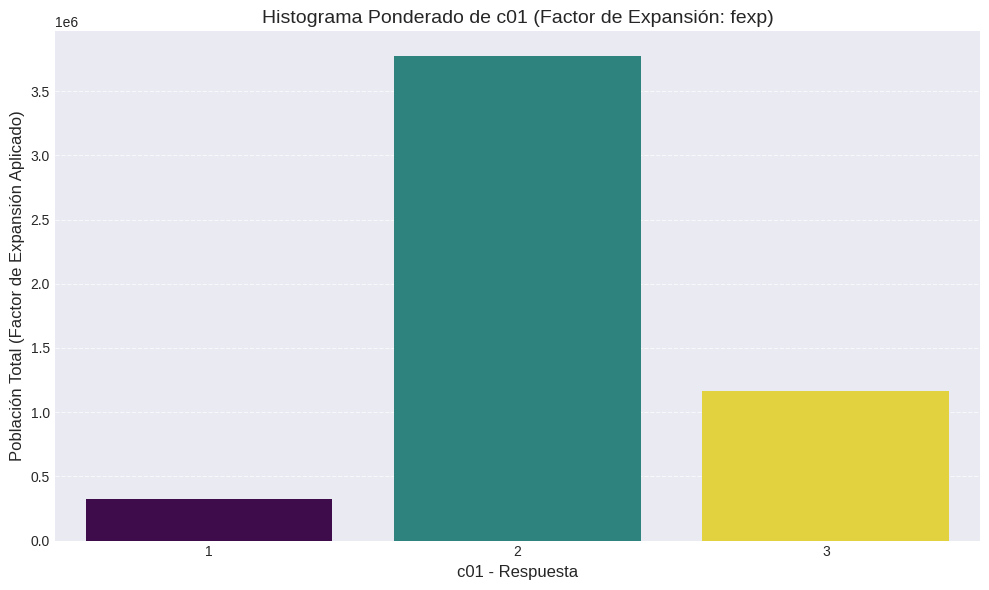


Distribución de c01 ponderada por fexp:

c01
1    3.260582e+05
2    3.777578e+06
3    1.165402e+06
Name: fexp, dtype: float64




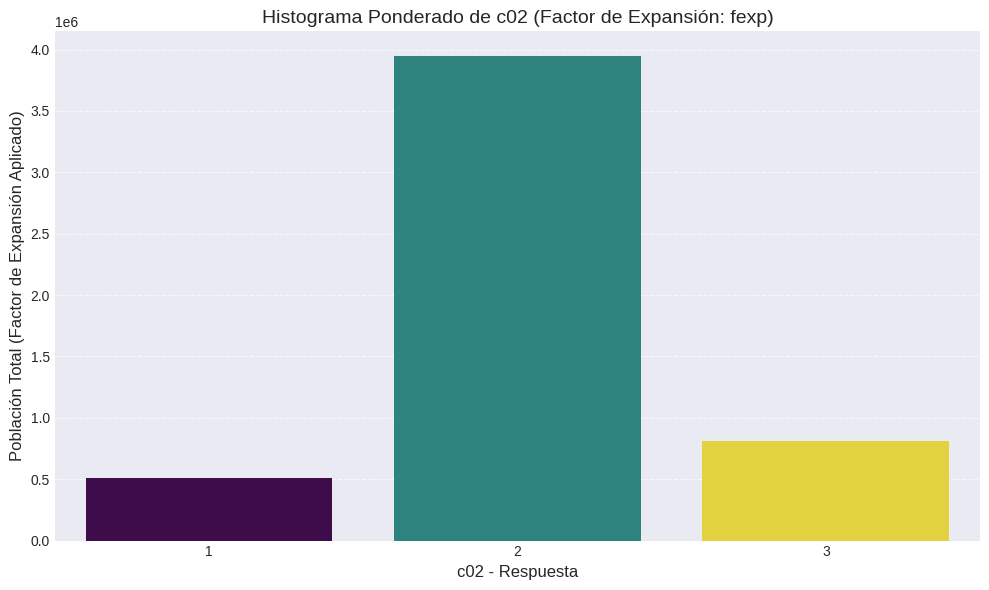


Distribución de c02 ponderada por fexp:

c02
1    5.062003e+05
2    3.950718e+06
3    8.121195e+05
Name: fexp, dtype: float64




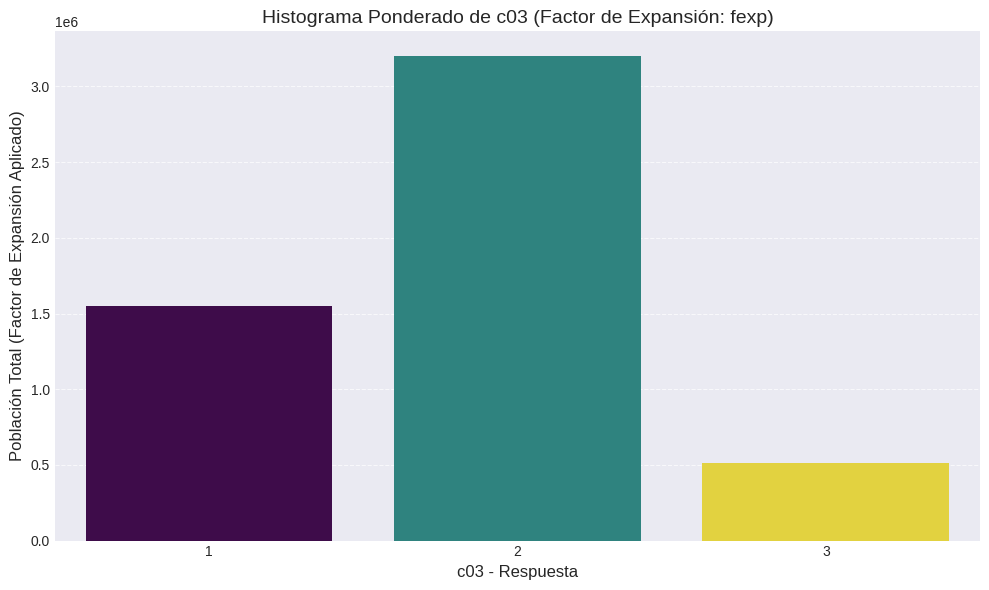


Distribución de c03 ponderada por fexp:

c03
1    1.551147e+06
2    3.204165e+06
3    5.137256e+05
Name: fexp, dtype: float64




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for dtype check

# Explicitly ensure 'fexp' is numeric with '.' as decimal separator
# This handles cases where df might have been loaded but fexp not converted or reverted.
if 'fexp' in df.columns and pd.api.types.is_string_dtype(df['fexp']):
   df['fexp'] = df['fexp'].str.replace(',', '.', regex=False).astype(float)

# List of columns to visualize with weighted histograms
columns_to_plot = ['c01', 'c02', 'c03']

plt.style.use('seaborn-v0_8-darkgrid')

for col in columns_to_plot:
    plt.figure(figsize=(10, 6))

    # Calculate weighted counts for each unique value
    weighted_counts = df.groupby(col)['fexp'].sum()

    # Create a bar plot from the weighted counts
    # Added 'hue' for better clarity and to address FutureWarning
    sns.barplot(x=weighted_counts.index, y=weighted_counts.values, hue=weighted_counts.index, palette='viridis', legend=False)

    plt.title(f'Histograma Ponderado de {col} (Factor de Expansión: fexp)', fontsize=14)
    plt.xlabel(f'{col} - Respuesta', fontsize=12)
    plt.ylabel('Población Total (Factor de Expansión Aplicado)', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print(f"\nDistribución de {col} ponderada por fexp:\n")
    print(weighted_counts)
    print("\n"+"="*50+"\n")

## 6. Distribución Binomial para `c01 = 1`

Esta sección se dedica al cálculo y visualización de la distribución binomial para los casos donde la variable `c01` asume el valor de 1. Se define la probabilidad de 'éxito' para esta condición y se representa gráficamente su Función de Masa de Probabilidad (PMF).

Es importante señalar que la distribución binomial aquí se basa en el **número de encuestas** y no en el factor de expansión (`fexp`). Consecuentemente, `n` representa el número total de registros (encuestas) y `p` es la proporción de encuestas donde la respuesta para `c01` es `1`.

Número total de encuestas (n): 8791
Número de encuestas con c01 = 1: 481
Probabilidad de que c01 sea 1 (p): 0.0547


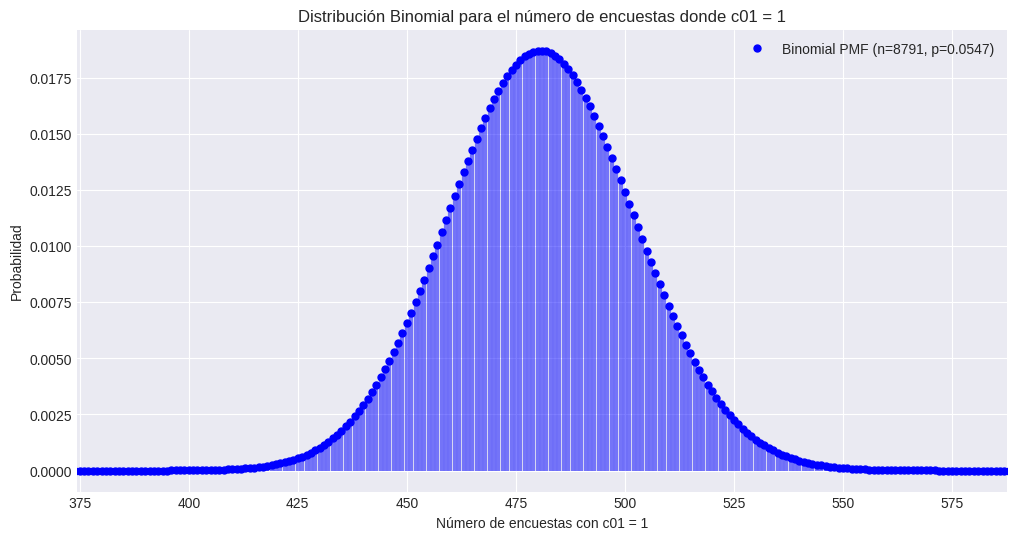


Media de la distribución Binomial: 481.0000
Varianza de la distribución Binomial: 454.6821
Desviación estándar de la distribución Binomial: 21.3233


In [ ]:
from scipy.stats import binom
import numpy as np # Ensure numpy is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported

# Calculate total number of surveys (n)
n_surveys = len(df)

# Calculate number of surveys where c01 == 1
success_count_c01_1 = df[df['c01'] == 1].shape[0]

# Calculate probability of success (p)
p_c01_1 = success_count_c01_1 / n_surveys

print(f"Número total de encuestas (n): {n_surveys}")
print(f"Número de encuestas con c01 = 1: {success_count_c01_1}")
print(f"Probabilidad de que c01 sea 1 (p): {p_c01_1:.4f}")

# Generate the binomial distribution (PMF)
k_values = np.arange(0, n_surveys + 1)
pmf = binom.pmf(k_values, n_surveys, p_c01_1)

# Plotting the binomial distribution
plt.figure(figsize=(12, 6))
plt.plot(k_values, pmf, 'bo', ms=5, label=f'Binomial PMF (n={n_surveys}, p={p_c01_1:.4f})')
plt.vlines(k_values, 0, pmf, colors='b', lw=3, alpha=0.5)

plt.title(f'Distribución Binomial para el número de encuestas donde c01 = 1')
plt.xlabel('Número de encuestas con c01 = 1')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(True)
plt.xlim(max(0, n_surveys * p_c01_1 - 5 * np.sqrt(n_surveys * p_c01_1 * (1 - p_c01_1))),
         min(n_surveys, n_surveys * p_c01_1 + 5 * np.sqrt(n_surveys * p_c01_1 * (1 - p_c01_1))))
plt.show()

# Calculate mean, variance, and standard deviation of the binomial distribution
mean_binomial = n_surveys * p_c01_1
variance_binomial = n_surveys * p_c01_1 * (1 - p_c01_1)
std_dev_binomial = np.sqrt(variance_binomial)

print(f"\nMedia de la distribución Binomial: {mean_binomial:.4f}")
print(f"Varianza de la distribución Binomial: {variance_binomial:.4f}")
print(f"Desviación estándar de la distribución Binomial: {std_dev_binomial:.4f}")

## 7. Distribución Binomial para `c01 = 2`

De forma análoga a la sección precedente, se analiza la distribución binomial para la variable `c01` cuando su valor es 2. Se calcula la probabilidad de su ocurrencia dentro del conjunto de encuestas y se visualiza su Función de Masa de Probabilidad (PMF), acompañada de sus estadísticas descriptivas clave (media, varianza y desviación estándar).

Número total de encuestas (n): 8791
Número de encuestas con c01 = 2: 6433
Probabilidad de que c01 sea 2 (p): 0.7318


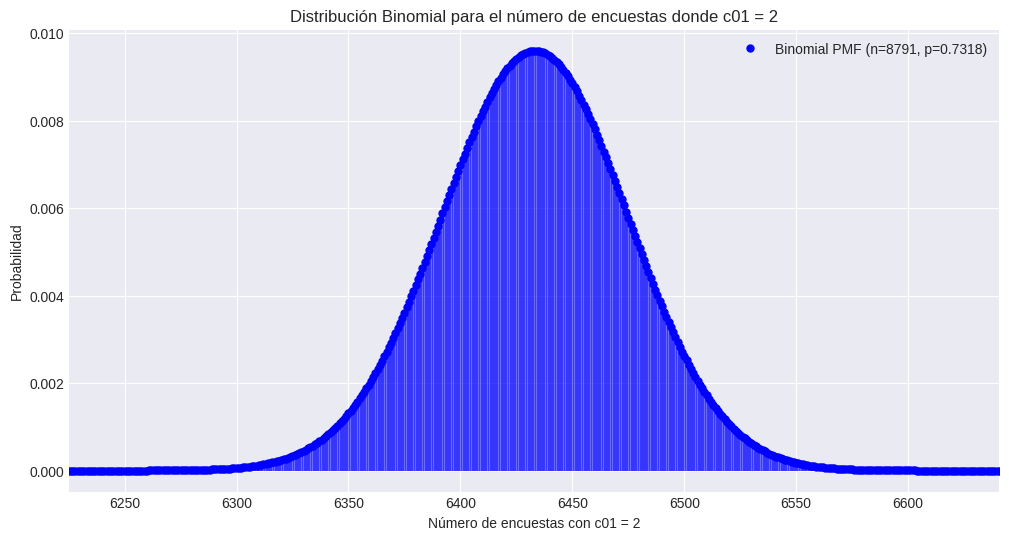


Media de la distribución Binomial: 6433.0000
Varianza de la distribución Binomial: 1725.5163
Desviación estándar de la distribución Binomial: 41.5393


In [ ]:
from scipy.stats import binom

# Calculate total number of surveys (n)
n_surveys = len(df)

# Calculate number of surveys where c01 == 2
success_count_c01_2 = df[df['c01'] == 2].shape[0]

# Calculate probability of success (p)
p_c01_2 = success_count_c01_2 / n_surveys

print(f"Número total de encuestas (n): {n_surveys}")
print(f"Número de encuestas con c01 = 2: {success_count_c01_2}")
print(f"Probabilidad de que c01 sea 2 (p): {p_c01_2:.4f}")

# Generate the binomial distribution (PMF)
k_values = np.arange(0, n_surveys + 1)
pmf = binom.pmf(k_values, n_surveys, p_c01_2)

# Plotting the binomial distribution
plt.figure(figsize=(12, 6))
plt.plot(k_values, pmf, 'bo', ms=5, label=f'Binomial PMF (n={n_surveys}, p={p_c01_2:.4f})')
plt.vlines(k_values, 0, pmf, colors='b', lw=3, alpha=0.5)

plt.title(f'Distribución Binomial para el número de encuestas donde c01 = 2')
plt.xlabel('Número de encuestas con c01 = 2')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(True)
plt.xlim(max(0, n_surveys * p_c01_2 - 5 * np.sqrt(n_surveys * p_c01_2 * (1 - p_c01_2))),
         min(n_surveys, n_surveys * p_c01_2 + 5 * np.sqrt(n_surveys * p_c01_2 * (1 - p_c01_2))))
plt.show()

# Calculate mean, variance, and standard deviation of the binomial distribution
mean_binomial = n_surveys * p_c01_2
variance_binomial = n_surveys * p_c01_2 * (1 - p_c01_2)
std_dev_binomial = np.sqrt(variance_binomial)

print(f"\nMedia de la distribución Binomial: {mean_binomial:.4f}")
print(f"Varianza de la distribución Binomial: {variance_binomial:.4f}")
print(f"Desviación estándar de la distribución Binomial: {std_dev_binomial:.4f}")

## 8. Distribución Binomial para `c01 = 3`

Esta sección concluye el análisis de la distribución binomial para la variable `c01`, enfocándose en los casos donde toma el valor de 3. Se determina la probabilidad de este 'éxito', se grafica su Función de Masa de Probabilidad (PMF) y se presentan sus estadísticas descriptivas fundamentales para una comprensión integral.

Número total de encuestas (n): 8791
Número de encuestas con c01 = 3: 1877
Probabilidad de que c01 sea 3 (p): 0.2135


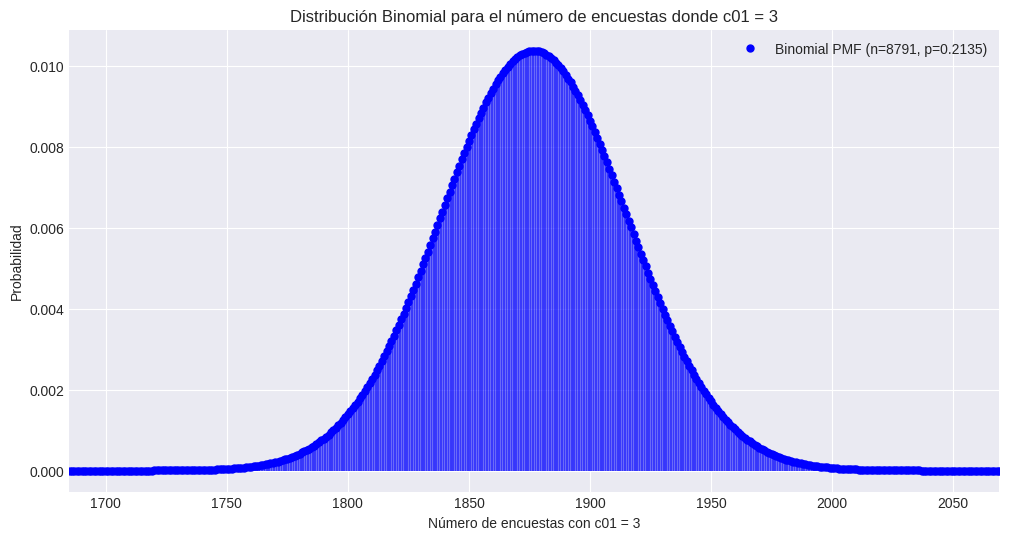


Media de la distribución Binomial: 1877.0000
Varianza de la distribución Binomial: 1476.2346
Desviación estándar de la distribución Binomial: 38.4218


In [ ]:
from scipy.stats import binom
import numpy as np # Ensure numpy is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported

# Calculate total number of surveys (n)
n_surveys = len(df)

# Calculate number of surveys where c01 == 3
success_count_c01_3 = df[df['c01'] == 3].shape[0]

# Calculate probability of success (p)
p_c01_3 = success_count_c01_3 / n_surveys

print(f"Número total de encuestas (n): {n_surveys}")
print(f"Número de encuestas con c01 = 3: {success_count_c01_3}")
print(f"Probabilidad de que c01 sea 3 (p): {p_c01_3:.4f}")

# Generate the binomial distribution (PMF)
k_values = np.arange(0, n_surveys + 1)
pmf = binom.pmf(k_values, n_surveys, p_c01_3)

# Plotting the binomial distribution
plt.figure(figsize=(12, 6))
plt.plot(k_values, pmf, 'bo', ms=5, label=f'Binomial PMF (n={n_surveys}, p={p_c01_3:.4f})')
plt.vlines(k_values, 0, pmf, colors='b', lw=3, alpha=0.5)

plt.title(f'Distribución Binomial para el número de encuestas donde c01 = 3')
plt.xlabel('Número de encuestas con c01 = 3')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(True)
plt.xlim(max(0, n_surveys * p_c01_3 - 5 * np.sqrt(n_surveys * p_c01_3 * (1 - p_c01_3))),
         min(n_surveys, n_surveys * p_c01_3 + 5 * np.sqrt(n_surveys * p_c01_3 * (1 - p_c01_3))))
plt.show()

# Calculate mean, variance, and standard deviation of the binomial distribution
mean_binomial = n_surveys * p_c01_3
variance_binomial = n_surveys * p_c01_3 * (1 - p_c01_3)
std_dev_binomial = np.sqrt(variance_binomial)

print(f"\nMedia de la distribución Binomial: {mean_binomial:.4f}")
print(f"Varianza de la distribución Binomial: {variance_binomial:.4f}")
print(f"Desviación estándar de la distribución Binomial: {std_dev_binomial:.4f}")

## 9. Explicación de las Funciones Manuales y el Parámetro `ddof=1`

### 9.1. Programación de Funciones Manuales

Las funciones manuales implementadas para calcular la esperanza matemática (media) y la varianza se desarrollaron utilizando bucles `for` y operaciones aritméticas básicas, en estricta conformidad con sus definiciones estadísticas:

*   **Esperanza Matemática (Media):** Se obtiene al sumar todos los valores observados de la variable de interés y dividir el total por el número de observaciones (`n`).
    *   Fórmula: `E[X] = (Σ xᵢ) / n`
*   **Varianza:**
    1.  En primer lugar, se calcula la media manual (E[X]).
    2.  Posteriormente, se itera sobre cada valor `xᵢ`, se le resta la media, se eleva el resultado al cuadrado, y se acumula esta suma (`Σ (xᵢ - E[X])²`).
    3.  Finalmente, este sumatorio se divide por `(n - 1)`. Esta particular división por `(n - 1)` es fundamental y está directamente relacionada con el concepto del parámetro `ddof=1`.
    *   Fórmula: `Var[X] = (Σ (xᵢ - E[X])²) / (n - 1)`

### 9.2. Impacto del Parámetro `ddof=1`

El parámetro `ddof` (Delta Degrees of Freedom, o grados de libertad de la diferencia) es un argumento clave en funciones estadísticas para el cálculo de la varianza y la desviación estándar. Mientras que su valor por defecto suele ser `0` (resultando en el cálculo de la varianza poblacional), para **muestras**, el uso de `ddof=1` es una práctica común y altamente recomendada.

*   **`ddof=0` (Varianza Poblacional):** La suma de los cuadrados de las diferencias se divide por `n` (el número total de observaciones).
    *   Fórmula: `Var_poblacional = (Σ (xᵢ - E[X])²) / n`
*   **`ddof=1` (Varianza Muestral Insesgada):** La suma de los cuadrados de las diferencias se divide por `n - 1`. Este es el estimador **insesgado** de la varianza poblacional cuando se trabaja con una muestra de datos.
    *   Fórmula: `Var_muestral = (Σ (xᵢ - E[X])²) / (n - 1)`

#### ¿Por qué `n - 1` para la varianza muestral?

Cuando la varianza de una muestra se calcula para estimar la varianza de la población de la cual proviene, se utiliza la media de la muestra (x̄) en lugar de la verdadera media poblacional (μ), que es desconocida. El uso de x̄ tiende a hacer que los residuos `(xᵢ - x̄)` sean ligeramente más pequeños de lo que serían si se conociera y utilizara μ. La división por `n - 1` en lugar de `n` corrige este sesgo, proporcionando un estimador más preciso y no sesgado de la varianza de la población.

En conclusión, el parámetro `ddof=1` es esencial para obtener estimaciones de varianza y desviación estándar que sean más adecuadas y menos sesgadas de los parámetros poblacionales cuando los cálculos se basan en una muestra de datos.

## 10. Conclusiones

Este análisis exploratorio de la encuesta ENEMDU ha proporcionado una comprensión detallada de varias variables clave y sus distribuciones. A continuación, se resumen las principales conclusiones:

*   **Factor de Expansión (`fexp`):** Se confirmó que el factor de expansión (`fexp`) sigue una distribución log-normal. Sus cálculos manuales y con NumPy demostraron consistencia. La esperanza matemática de `fexp` indica que, en promedio, cada registro de la encuesta representa a un número significativo de individuos en la población, subrayando la importancia de esta variable para la extrapolación de resultados.

*   **Variable `area` (Binaria):** La variable `area` fue exitosamente transformada en una variable binaria (éxito/fracaso) para su análisis con una distribución de Bernoulli. Se calculó la probabilidad de éxito (`p`), que representa la proporción de encuestas en el 'Área 1'. La coherencia entre los cálculos manuales y los de NumPy para la esperanza matemática y la varianza de Bernoulli valida el enfoque.

*   **Histogramas Ponderados (`c01`, `c02`, `c03`):** La generación de histogramas ponderados utilizando `fexp` para las variables `c01`, `c02` y `c03` permitió visualizar sus distribuciones reales en la población. Esto es crucial para entender la frecuencia relativa de cada categoría de respuesta, superando las limitaciones de un conteo simple no ponderado.

*   **Distribuciones Binomiales (`c01=1`, `c01=2`, `c01=3`):** Se analizaron las distribuciones binomiales para las diferentes categorías de la variable `c01` (cuando `c01` toma los valores de 1, 2 y 3). Esto reveló la probabilidad de observar un cierto número de éxitos (es decir, el número de encuestas donde `c01` toma un valor específico) dentro del total de encuestas. Estos análisis resaltan cómo la distribución binomial puede modelar eventos discretos y dicotómicos en el contexto de una encuesta. La media y la varianza de cada distribución confirmaron las expectativas teóricas para la distribución binomial.